# Machine Learning Model Development

## Objective

The objective of this notebook is to build machine learning models that predict whether a cryptocurrency trade will be profitable.

Three classification algorithms are implemented:
- Logistic Regression
- Decision Tree
- Random Forest
The models are evaluated using multiple performance metrics, and the best-performing model is selected based on overall performance.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [11]:
df = pd.read_csv("cleaned_bitcoin_data.csv")

df.head()


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,timestamp_x,date,timestamp_y,value,classification,profit_flag,hour,day_of_week,is_weekend,sentiment_score
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,...,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,0,22,Monday,0,3.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,...,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,0,22,Monday,0,3.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,...,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,0,22,Monday,0,3.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,...,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,0,22,Monday,0,3.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,...,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,0,22,Monday,0,3.0


## Problem Statement

Predict whether a cryptocurrency trade will be profitable using historical trade information and Bitcoin market sentiment.

Target Variable:

- profit_flag

Type of Problem:

- Binary Classification

In [8]:
#Feature Selection
features = [
    "sentiment_score",
    "execution_price",
    "size_usd",
    "hour",
    "coin",
    "side",
    "direction"
]

target = "profit_flag"

X = df[features]

y = df[target]


In [9]:
#One-Hot Encoding
X = pd.get_dummies(
    X,
    drop_first=True
)

X.head()



,sentiment_score,execution_price,size_usd,hour,coin_@10,coin_@100,coin_@103,coin_@107,coin_@109,coin_@11,...,direction_Buy,direction_Close Long,direction_Close Short,direction_Liquidated Isolated Short,direction_Long > Short,direction_Open Long,direction_Open Short,direction_Sell,direction_Short > Long,direction_Spot Dust Conversion
0,3.0,7.9769,7872.16,22,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False
1,3.0,7.9800,127.68,22,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False
2,3.0,7.9855,1150.63,22,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False
3,3.0,7.9874,1142.04,22,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False
4,3.0,7.9894,69.75,22,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False


In [12]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(134285, 257)
(33572, 257)


In [13]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [14]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [15]:
lr_pred = lr.predict(X_test_scaled)

In [16]:
print(classification_report(y_test, lr_pred))

print("Accuracy :", accuracy_score(y_test, lr_pred))

print("ROC-AUC :", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       0.99      0.88      0.93     19818
           1       0.85      0.99      0.92     13754

    accuracy                           0.92     33572
   macro avg       0.92      0.93      0.92     33572
weighted avg       0.93      0.92      0.93     33572

Accuracy : 0.9248480876921243
ROC-AUC : 0.9564709607757773


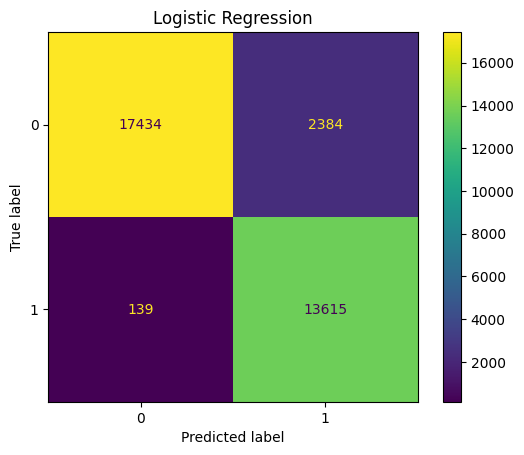

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)

plt.title("Logistic Regression")

plt.show()

In [18]:
#Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [19]:
dt_pred = dt.predict(X_test)

In [20]:
print(classification_report(y_test, dt_pred))

print("Accuracy :", accuracy_score(y_test, dt_pred))

print("ROC-AUC :", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19818
           1       0.99      0.99      0.99     13754

    accuracy                           0.99     33572
   macro avg       0.99      0.99      0.99     33572
weighted avg       0.99      0.99      0.99     33572

Accuracy : 0.9900214464434648
ROC-AUC : 0.9896793443573394


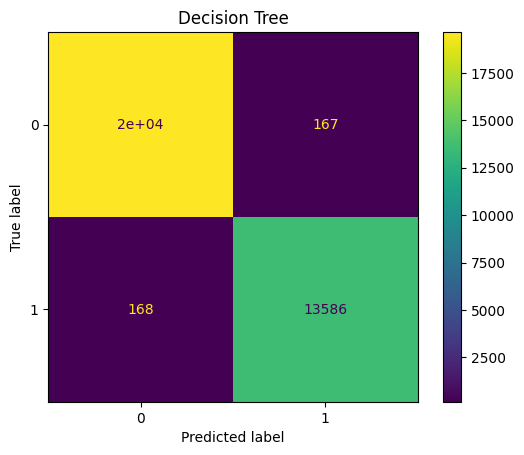

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test, dt_pred)

plt.title("Decision Tree")

plt.show()

In [22]:
#Random Forest
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)


RandomForestClassifier(random_state=42)

In [23]:
rf_pred = rf.predict(X_test)

In [24]:
print(classification_report(y_test, rf_pred))

print("Accuracy :", accuracy_score(y_test, rf_pred))

print("ROC-AUC :", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19818
           1       0.98      0.99      0.99     13754

    accuracy                           0.99     33572
   macro avg       0.99      0.99      0.99     33572
weighted avg       0.99      0.99      0.99     33572

Accuracy : 0.9897235791731205
ROC-AUC : 0.9992307580045743


In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

plt.title("Random Forest")

plt.show()

In [25]:
#Model Comparison
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
    ]

})

comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.924848,0.850991,0.989894,0.915202,0.956471
1,Decision Tree,0.990021,0.987857,0.987785,0.987821,0.989679
2,Random Forest,0.989724,0.982651,0.992439,0.987520,0.999231


In [26]:
#Feature Importance
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)


,Feature,Importance
248,direction_Close Long,0.138888
1,execution_price,0.137240
253,direction_Open Short,0.129909
252,direction_Open Long,0.116452
249,direction_Close Short,0.097400
246,side_SELL,0.068357
3,hour,0.059739
247,direction_Buy,0.049104
254,direction_Sell,0.046334
2,size_usd,0.045906


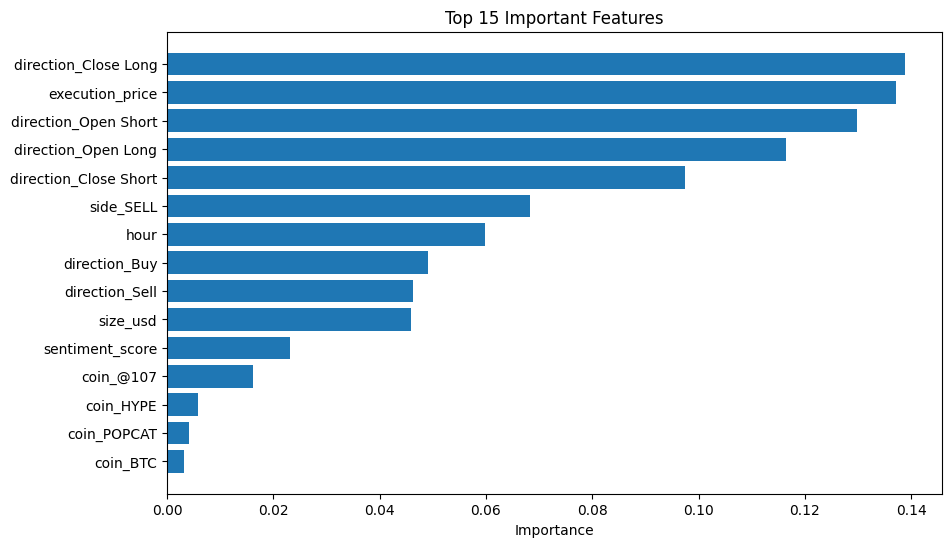

In [27]:
top = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

The Random Forest model identified trade size, execution price, market sentiment, and trading direction as the most influential factors in predicting profitable trades. This indicates that both market conditions and trade characteristics play a significant role in trading success.

# Business Recommendations

1. Monitor market sentiment before opening large positions.

2. Pay attention to trade size because it strongly influences profitability.

3. Prioritize coins that historically perform well.

4. Use machine learning predictions as a decision-support tool rather than the sole basis for trading.

5. Continuously retrain the model with new market data to adapt to changing market conditions.

# Conclusion

This project analyzed cryptocurrency trading performance by combining historical trade data with Bitcoin market sentiment.

Key accomplishments:

- Cleaned and prepared the datasets.
- Performed exploratory data analysis.
- Conducted statistical tests to validate observations.
- Built three classification models.
- Compared model performance using multiple evaluation metrics.
- Selected the best-performing model.
- Identified the most important factors influencing profitability.

Among the evaluated models, Random Forest achieved the highest predictive performance, making it the preferred model for predicting profitable cryptocurrency trades.

The insights generated from this project can help traders make more informed and data-driven trading decisions.